# Property Sales — Exploratory Data Analysis

**Dataset:** `properties.csv` — 100 residential properties
**Author:** Waheed

This notebook performs a structured exploratory data analysis (EDA) of a property
sales dataset. The goal is to understand the dataset's key characteristics through
four lenses:

1. **Distribution analysis** — how each variable is spread
2. **Relationship analysis** — how size, location and price relate
3. **Correlation analysis** — the strength of the size–price link
4. **Outlier detection** — identifying anomalous properties

Each visualization is followed by a written interpretation of the trends, patterns,
correlations and anomalies it reveals.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# --- Load data (change the path if you move the file next to this notebook) ---
CSV_PATH = r"C:\Users\Waheed\Downloads\properties.csv"
df = pd.read_csv(CSV_PATH)
df.head()

,PropertyID,Location,Size_sqft,SalePrice
0,2001,Suburb,2996,355372
1,2002,Downtown,2887,505830
2,2003,Suburb,957,338789
3,2004,Countryside,1814,419335
4,2005,Suburb,850,357301


## 1. Dataset overview

Before visualizing, we establish the structure and quality of the data.

| Column | Meaning |
|--------|---------|
| `PropertyID` | Unique identifier (not a predictor) |
| `Location` | Neighbourhood type: Suburb, Downtown, Countryside |
| `Size_sqft` | Floor area in square feet |
| `SalePrice` | Sale price in USD (target variable) |

In [2]:
print("Shape:", df.shape)
df.info()
print("\nMissing values:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nLocation counts:\n", df["Location"].value_counts())
df.describe()

Shape: (100, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   PropertyID  100 non-null    int64 
 1   Location    100 non-null    object
 2   Size_sqft   100 non-null    int64 
 3   SalePrice   100 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 3.3+ KB

Missing values:
 PropertyID    0
Location      0
Size_sqft     0
SalePrice     0
dtype: int64

Duplicate rows: 0

Location counts:
 Location
Suburb         40
Downtown       36
Countryside    24
Name: count, dtype: int64


,PropertyID,Size_sqft,SalePrice
count,100.000000,100.000000,100.000000
mean,2050.500000,1832.410000,401866.300000
std,29.011492,695.535926,116274.958848
min,2001.000000,806.000000,205943.000000
25%,2025.750000,1154.000000,303015.500000
50%,2050.500000,1816.000000,403301.500000
75%,2075.250000,2438.000000,506435.250000
max,2100.000000,2996.000000,598378.000000


**Interpretation — overview.**
The dataset is clean and complete: **100 properties, 4 columns, no missing values and
no duplicates**, with all `PropertyID`s unique. `Size_sqft` ranges from ~806 to ~2,996
sqft (mean ≈ 1,832) and `SalePrice` from ~$205,900 to ~$598,400 (mean ≈ $401,900).
The three location categories are unevenly represented — **Suburb (40), Downtown (36),
Countryside (24)** — which we should keep in mind when comparing groups.

## 2. Distribution analysis

We examine how each variable is distributed: the two numeric variables via histograms
(with a KDE curve), and the categorical `Location` via a count plot.

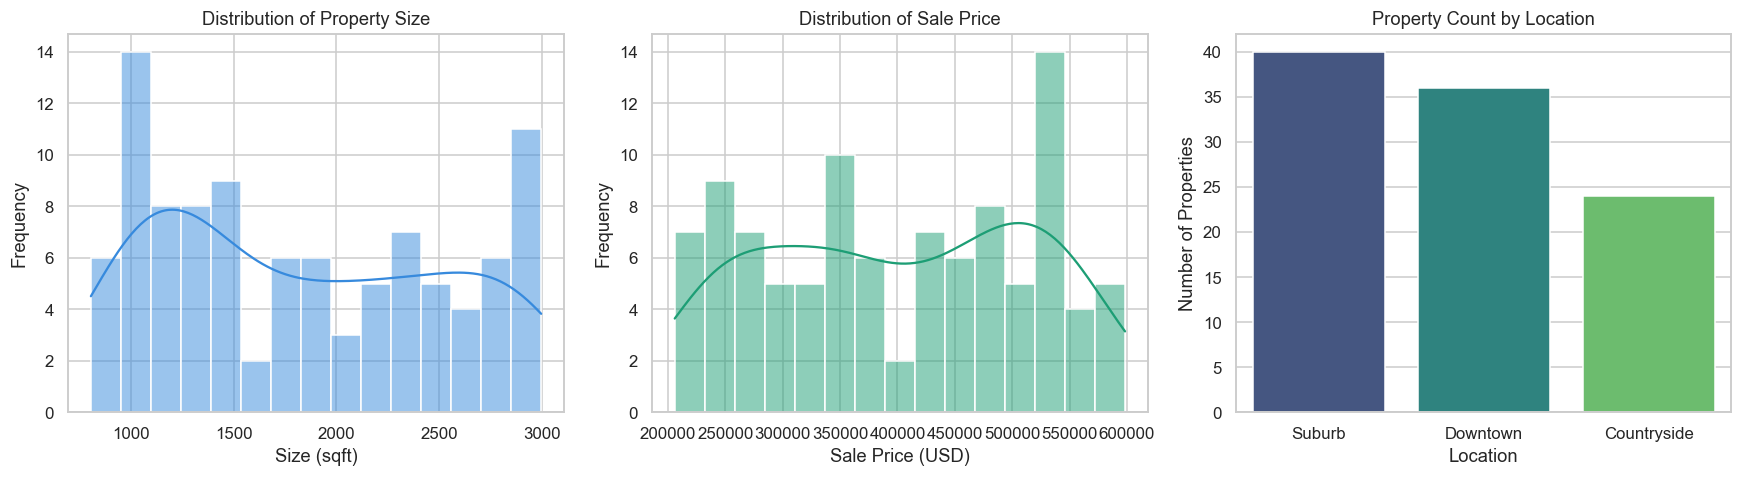

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.histplot(df["Size_sqft"], bins=15, kde=True, color="#378ADD", ax=axes[0])
axes[0].set_title("Distribution of Property Size")
axes[0].set_xlabel("Size (sqft)"); axes[0].set_ylabel("Frequency")

sns.histplot(df["SalePrice"], bins=15, kde=True, color="#1D9E75", ax=axes[1])
axes[1].set_title("Distribution of Sale Price")
axes[1].set_xlabel("Sale Price (USD)"); axes[1].set_ylabel("Frequency")

sns.countplot(data=df, x="Location", hue="Location", legend=False,
              order=df["Location"].value_counts().index, palette="viridis", ax=axes[2])
axes[2].set_title("Property Count by Location")
axes[2].set_xlabel("Location"); axes[2].set_ylabel("Number of Properties")

plt.tight_layout(); plt.show()

**Interpretation — distributions.**
Both numeric variables are **remarkably flat / near-uniform** rather than bell-shaped:
the histograms show roughly even bar heights across the whole range and the **KDE curves
are almost horizontal**, with no single dominant peak. In real housing data we would
expect `SalePrice` to be right-skewed (a long tail of expensive homes); its absence here
strongly suggests the data was **synthetically generated for teaching purposes**.
The count plot shows the location imbalance clearly — Suburb is the most common category
and Countryside the least.

## 3. Relationship analysis

Does a larger property, or a particular location, command a higher price? We use a
scatter plot (size vs price, coloured by location) and a box plot (price by location).

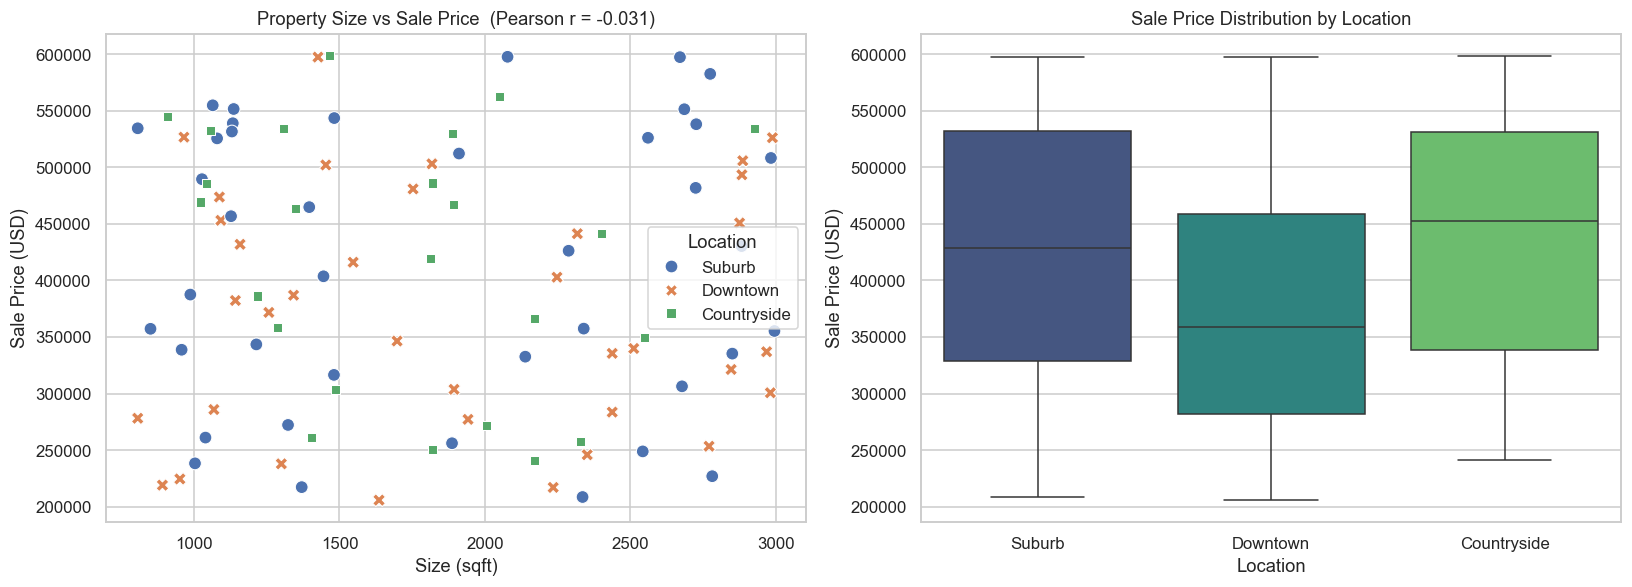

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

r = df["Size_sqft"].corr(df["SalePrice"])
sns.scatterplot(data=df, x="Size_sqft", y="SalePrice", hue="Location",
                style="Location", s=70, ax=axes[0])
axes[0].set_title(f"Property Size vs Sale Price  (Pearson r = {r:.3f})")
axes[0].set_xlabel("Size (sqft)"); axes[0].set_ylabel("Sale Price (USD)")

sns.boxplot(data=df, x="Location", y="SalePrice", hue="Location", legend=False,
            palette="viridis", ax=axes[1])
axes[1].set_title("Sale Price Distribution by Location")
axes[1].set_xlabel("Location"); axes[1].set_ylabel("Sale Price (USD)")

plt.tight_layout(); plt.show()

**Interpretation — relationships.**
The scatter plot is a **shapeless cloud with no upward or downward slope** — as size
increases, price does not systematically change (Pearson r ≈ **-0.03**). The location
colours are **thoroughly intermixed** rather than forming separate bands, so neighbourhood
does not visibly stratify price either. The box plot confirms this: the three boxes
**overlap heavily**, with Downtown sitting only slightly lower (median ≈ $371k vs ≈ $418k
Suburb and ≈ $421k Countryside). **Conclusion: neither size nor location is a meaningful
driver of price in this dataset.**

## 4. Correlation analysis

We quantify the linear relationship between the numeric variables with a correlation
heatmap.

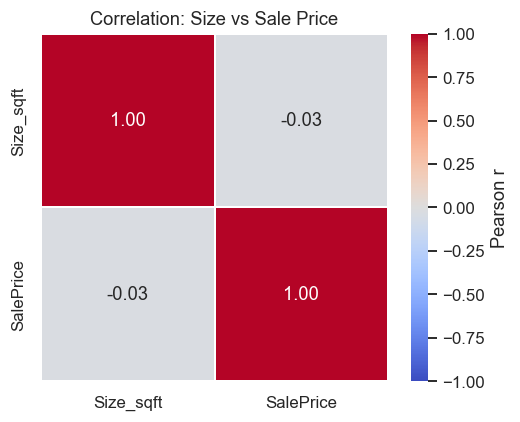

In [5]:
corr = df[["Size_sqft", "SalePrice"]].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            center=0, square=True, linewidths=1, cbar_kws={"label": "Pearson r"})
plt.title("Correlation: Size vs Sale Price")
plt.tight_layout(); plt.show()

**Interpretation — correlation.**
The diagonal cells are 1.00 by definition (each variable with itself). The informative
cell is the off-diagonal value of **-0.03**, rendered in a near-neutral colour on the
diverging scale. A value this close to zero means there is **effectively no linear
relationship** between floor area and sale price — visually confirming the flat scatter
plot above. Practically, this tells us a linear regression of price on size would have an
**R² close to zero** and little predictive power.

## 5. Outlier detection

We check for anomalies in two ways: **univariate** (each column on its own, via box plots
and the IQR rule) and **bivariate** (unusual price *relative to size*, via price-per-sqft).

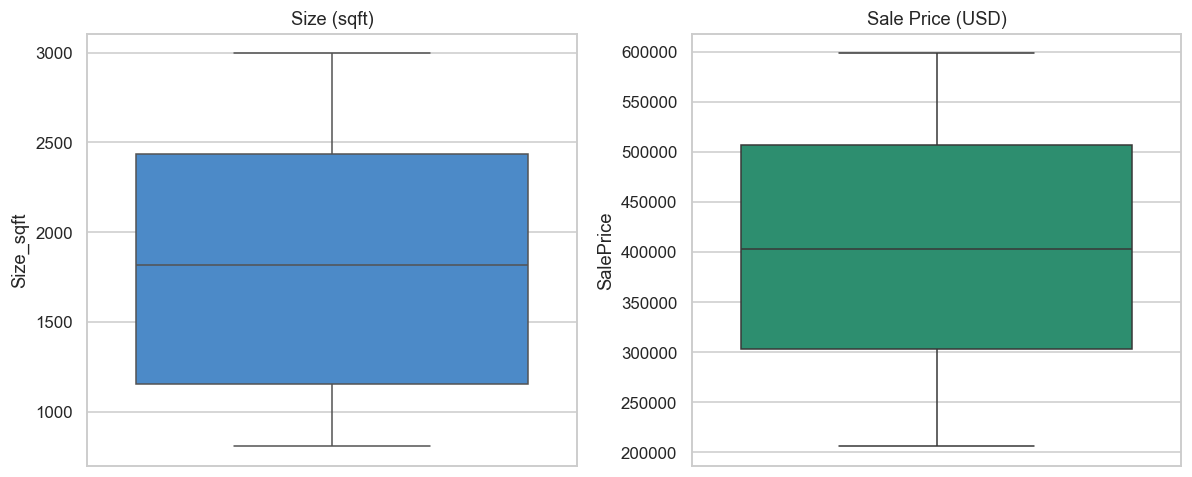

Size_sqft : 0 IQR outliers | max |z-score| = 1.67
SalePrice : 0 IQR outliers | max |z-score| = 1.69


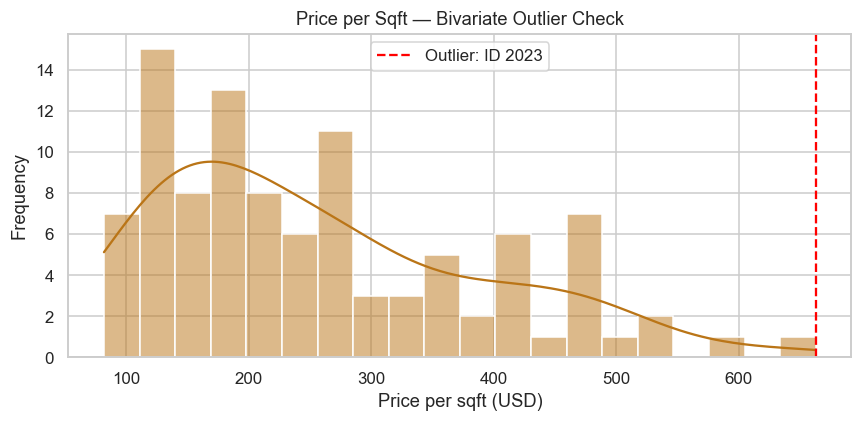


Bivariate outliers (unusual price for size):


,PropertyID,Location,Size_sqft,SalePrice,PricePerSqft
22,2023,Suburb,806,534479,663.1


In [6]:
# --- Univariate: box plots ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.boxplot(y=df["Size_sqft"], color="#378ADD", ax=axes[0])
axes[0].set_title("Size (sqft)")
sns.boxplot(y=df["SalePrice"], color="#1D9E75", ax=axes[1])
axes[1].set_title("Sale Price (USD)")
plt.tight_layout(); plt.show()

# --- Univariate: IQR rule ---
for col in ["Size_sqft", "SalePrice"]:
    q1, q3 = df[col].quantile([0.25, 0.75]); iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n = ((df[col] < low) | (df[col] > high)).sum()
    z_max = ((df[col] - df[col].mean()) / df[col].std()).abs().max()
    print(f"{col:10s}: {n} IQR outliers | max |z-score| = {z_max:.2f}")

# --- Bivariate: price per square foot ---
df["PricePerSqft"] = df["SalePrice"] / df["Size_sqft"]
q1, q3 = df["PricePerSqft"].quantile([0.25, 0.75]); iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
biv = df[(df["PricePerSqft"] < low) | (df["PricePerSqft"] > high)]

plt.figure(figsize=(8, 4))
sns.histplot(df["PricePerSqft"], bins=20, kde=True, color="#BA7517")
for _, row in biv.iterrows():
    plt.axvline(row["PricePerSqft"], color="red", linestyle="--",
                label=f"Outlier: ID {int(row['PropertyID'])}")
plt.title("Price per Sqft — Bivariate Outlier Check")
plt.xlabel("Price per sqft (USD)"); plt.ylabel("Frequency")
if len(biv): plt.legend()
plt.tight_layout(); plt.show()

print("\nBivariate outliers (unusual price for size):")
biv[["PropertyID", "Location", "Size_sqft", "SalePrice", "PricePerSqft"]].round(1)

**Interpretation — outliers.**
By standard **univariate** measures there are **no outliers at all**: the IQR rule flags
zero rows in either column, and the maximum absolute z-score is only ~1.7 (well under the
usual threshold of 3). The box-plot whiskers contain every point. This tameness is another
fingerprint of synthetic data.

However, engineering a **bivariate** feature — price *per square foot* — reveals **one
anomaly: PropertyID 2023**, an 806 sqft Suburb home selling for $534,479, i.e. **~$663/sqft**,
far above the rest of the market. It is invisible to univariate checks because neither its
size nor its price is individually extreme — only their *combination* is unusual.

**Why might a small home be so expensive?** With only size and location recorded, the
honest answer is that **the dataset cannot explain it** — every real price driver
(lot size, condition, renovations, exact location, amenities) is an *omitted variable*.
In real data such a point would also warrant a check for a **data-entry error**. Given the
synthetic nature here, it is most likely a random artifact of how the data was generated.

## 6. Summary of findings

- **Data quality:** 100 properties, complete and duplicate-free.
- **Distributions:** `Size_sqft` and `SalePrice` are near-uniform (not bell-shaped);
  locations are imbalanced (Suburb > Downtown > Countryside).
- **Relationships:** no visible link between size and price; locations overlap heavily.
- **Correlation:** size–price Pearson r ≈ **-0.03** → effectively no linear relationship.
- **Outliers:** none univariate; **one bivariate** (ID 2023, ~$663/sqft).
- **Overall:** the dataset behaves like **synthetic, educational data** — price is
  essentially independent of the recorded features, so it would not support a predictive
  model. The value of this EDA is in *demonstrating the techniques* and in recognising,
  through the data itself, that the recorded variables do not determine price.